In [86]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import holidays
import numpy as np

In [2]:
data = pd.read_excel("data/energy_profile.xlsx", header=2)
data.drop(columns=["Unnamed: 0"], inplace=True)

months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
data_types = ["SA", "FT", "WT"]
new_months = []
for month in months:
  for data_type in data_types:
    new_months.append(month+"_"+data_type)

data.columns = ["Time"] + new_months
data.drop(index=0, inplace=True)
data.dropna(axis=0,subset=["Time"], inplace=True)

data = data.melt(id_vars="Time")

data.columns = ["Time Period", "Date", "value"]
data["month_name"] = data.Date.apply(lambda x: x.split("_")[0])
data["day_type"] = data.Date.apply(lambda x: x.split("_")[1])
data["time"] = data["Time Period"].apply(lambda x: x.split("-")[0])
data["time"] = pd.to_datetime(data["time"], format="%H:%M").dt.time

data.drop(columns=["Date", "Time Period"], inplace=True)


In [3]:
day_map = {
  "Monday": "WT",
  "Tuesday": "WT",
  "Wednesday": "WT",
  "Thursday": "WT",
  "Friday": "WT",
  "Saturday": "SA",
  "Sunday": "FT"
}

de_holidays = holidays.Germany(years=2025)

# 1. Create all 15-minute timestamps for 2025
dt_index = pd.date_range(
    start="2025-01-01 00:00",
    end="2025-12-31 23:45",   # last 15-minute slot of the year
    freq="15min"
)

df = pd.DataFrame({"datetime": dt_index})

# 2. Add date, time, weekday name
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["weekday"] = df["datetime"].dt.day_name() 
df["month_name"] = df["datetime"].dt.month_name()
# df["weekday"] = df["datetime"].dt.day_name(locale="de_DE")  # if you have locale set up
# Name of holiday (or None)
df["holiday_name"] = df["datetime"].dt.date.map(de_holidays.get)

# Boolean flag for “is public holiday?”
df["is_holiday"] = df["holiday_name"].notna()
df["day_type"] = df["weekday"].map(day_map)
df.loc[df["is_holiday"], "day_type"] = "FT"

pd.set_option("display.max_rows", 10)

df = df.merge(
  data,
  on = ["month_name", "day_type", "time"],
  how="left"
).drop(columns=["day_type", "time", "date", "holiday_name", "is_holiday"])

df = df.set_index("datetime")

df_hourly = pd.DataFrame(df.resample("h")["value"].mean()).reset_index()

df_hourly

,datetime,value
0,2025-01-01 00:00:00,14.4835
1,2025-01-01 01:00:00,14.15175
2,2025-01-01 02:00:00,13.97275
3,2025-01-01 03:00:00,13.861
4,2025-01-01 04:00:00,13.95375
...,...,...
8755,2025-12-31 19:00:00,27.46925
8756,2025-12-31 20:00:00,23.03
8757,2025-12-31 21:00:00,20.19275
8758,2025-12-31 22:00:00,17.676


In [4]:
pd.set_option("display.max_rows", 100)
# df[df.value.isna()].tail(40)

In [5]:
df[df.weekday=="Saturday"]["value"].sum()

103038.98000000032

In [6]:
day_ahead = pd.read_csv("data/day_ahead_2025.csv", sep=";")
day_ahead.head(2)

,Start date,End date,Germany/Luxembourg [€/MWh] Original resolutions,∅ DE/LU neighbours [€/MWh] Original resolutions,Belgium [€/MWh] Original resolutions,Denmark 1 [€/MWh] Original resolutions,Denmark 2 [€/MWh] Original resolutions,France [€/MWh] Original resolutions,Netherlands [€/MWh] Original resolutions,Norway 2 [€/MWh] Original resolutions,Austria [€/MWh] Original resolutions,Poland [€/MWh] Original resolutions,Sweden 4 [€/MWh] Original resolutions,Switzerland [€/MWh] Original resolutions,Czech Republic [€/MWh] Original resolutions,DE/AT/LU [€/MWh] Original resolutions,Northern Italy [€/MWh] Original resolutions,Slovenia [€/MWh] Original resolutions,Hungary [€/MWh] Original resolutions
0,"Jan 1, 2025 12:00 AM","Jan 1, 2025 12:15 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25
1,"Jan 1, 2025 12:15 AM","Jan 1, 2025 12:30 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25


In [7]:
day_ahead = day_ahead[["Start date", "End date", "Germany/Luxembourg [€/MWh] Original resolutions", "∅ DE/LU neighbours [€/MWh] Original resolutions"]]

day_ahead.columns = ["start_date", "end_date", "de_price", "neighbour_price"]
day_ahead["start_date"] = pd.to_datetime(day_ahead["start_date"], format="%b %d, %Y %I:%M %p")
day_ahead["end_date"] = pd.to_datetime(day_ahead["end_date"], format="%b %d, %Y %I:%M %p")
day_ahead.head()

,start_date,end_date,de_price,neighbour_price
0,2025-01-01 00:00:00,2025-01-01 00:15:00,2.16,27.99
1,2025-01-01 00:15:00,2025-01-01 00:30:00,2.16,27.99
2,2025-01-01 00:30:00,2025-01-01 00:45:00,2.16,27.99
3,2025-01-01 00:45:00,2025-01-01 01:00:00,2.16,27.99
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.60,29.36


In [8]:
df_combined = df_hourly.merge(
    day_ahead[["start_date", "de_price", "neighbour_price"]],
    left_on="datetime",
    right_on="start_date",
    how="left"
).drop(columns=["start_date"])

df_combined.head()

,datetime,value,de_price,neighbour_price
0,2025-01-01 00:00:00,14.4835,2.16,27.99
1,2025-01-01 01:00:00,14.15175,1.60,29.36
2,2025-01-01 02:00:00,13.97275,0.00,25.86
3,2025-01-01 03:00:00,13.861,-0.01,22.10
4,2025-01-01 04:00:00,13.95375,-0.01,20.38


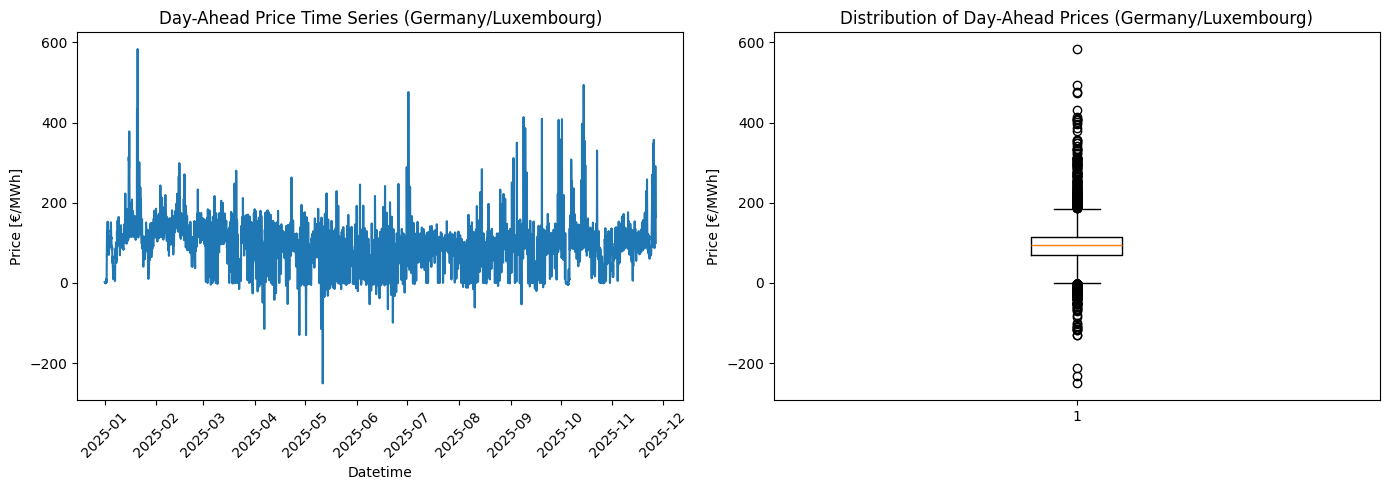

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series plot
axes[0].plot(df_combined["datetime"], df_combined["de_price"])
axes[0].set_title("Day-Ahead Price Time Series (Germany/Luxembourg)")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Price [€/MWh]")
for tl in axes[0].get_xticklabels():
  tl.set_rotation(45)

# Boxplot
axes[1].boxplot(df_combined["de_price"].dropna())
axes[1].set_title("Distribution of Day-Ahead Prices (Germany/Luxembourg)")
axes[1].set_ylabel("Price [€/MWh]")

plt.tight_layout()


In [10]:
day_ahead_hourly = pd.DataFrame(df_combined.resample("h", on="datetime")["de_price"].mean()).reset_index()
day_ahead_hourly.head(3)

,datetime,de_price
0,2025-01-01 00:00:00,2.16
1,2025-01-01 01:00:00,1.60
2,2025-01-01 02:00:00,0.00


In [ ]:
ANNUAL_USAGE = 2_00_000
SCALE_FACTOR = ANNUAL_USAGE /1_000_000
FLAT_RATE_C_PER_KWH = 30
BATTERY_INEFFICIENCY_FACTOR = 1.2 # The amount of extra electricity we need to store 
ELECTRICITY_SHIFT_PROPORTION = 0.5

# additional costs
NETWORK_USAGE = 8.71
TAX_RATE = 0.19
ELECTRICITY_TAX = 2.05
ADDITIONAL_COST = 1.88
KONZESSION = 1.66
CHP_SURCHARGE = 0.45
COMBINED_ADDITIONAL_COSTS = NETWORK_USAGE + ELECTRICITY_TAX + ADDITIONAL_COST + KONZESSION + CHP_SURCHARGE 

df_usage_and_price = df_hourly.merge(
    day_ahead_hourly,
    on="datetime",
    how="left"
).rename(columns={"de_price": "c_per_kwh_variable", "value": "raw_kwh_usage"})

df_usage_and_price["c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"] / 10 # Convert €/MWh to c€/kWh

# Fill missing prices with average price
df_usage_and_price.loc[df_usage_and_price.c_per_kwh_variable.isna(), "c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"].mean()
df_usage_and_price["scaled_kwh_usage"] = df_usage_and_price["raw_kwh_usage"] * SCALE_FACTOR
df_usage_and_price["c_fixed_costs_kwh"] = COMBINED_ADDITIONAL_COSTS

df_usage_and_price["c_variable_and_fixed_per_kwh"] = df_usage_and_price["c_per_kwh_variable"] + df_usage_and_price["c_fixed_costs_kwh"]

df_usage_and_price["c_total_variable_cost"] = (
    (df_usage_and_price["scaled_kwh_usage"] * (df_usage_and_price["c_variable_and_fixed_per_kwh"])) * (1 + TAX_RATE)
)

df_usage_and_price["c_per_kwh_flat_rate_cost"] = FLAT_RATE_C_PER_KWH
df_usage_and_price["c_total_flat_cost"] = (df_usage_and_price["c_per_kwh_flat_rate_cost"] * df_usage_and_price["scaled_kwh_usage"]) * (1+TAX_RATE)


df_usage_and_price.head(3)

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_variable_and_fixed_per_kwh,c_total_variable_cost,c_per_kwh_flat_rate_cost,c_total_flat_cost
0,2025-01-01 00:00:00,14.4835,0.216,2.8967,14.75,14.966,51.588895,30,103.41219
1,2025-01-01 01:00:00,14.15175,0.160,2.83035,14.75,14.910,50.218617,30,101.043495
2,2025-01-01 02:00:00,13.97275,0.000,2.79455,14.75,14.750,49.051339,30,99.765435


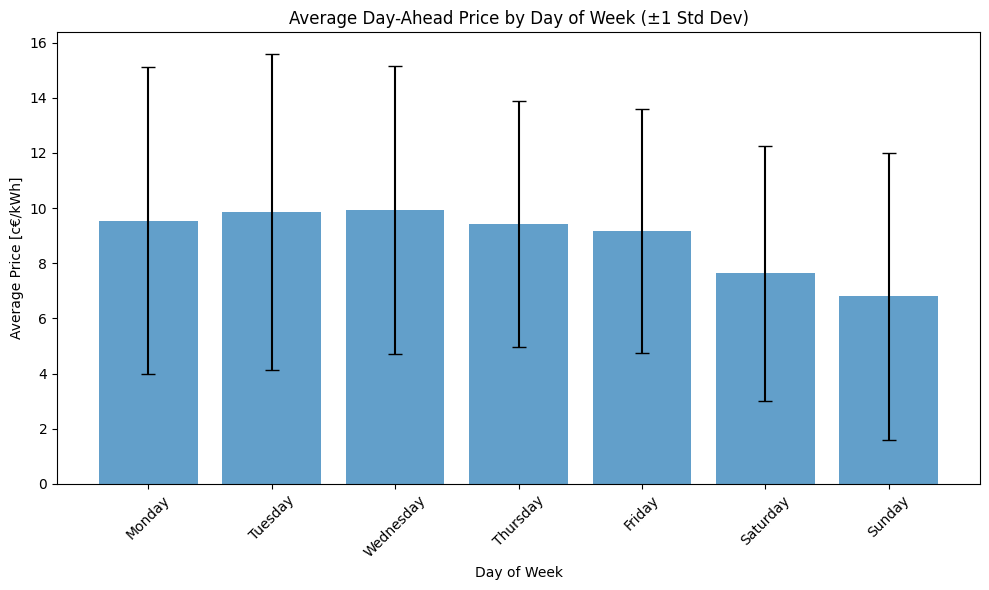

In [224]:
# Group by day of week and calculate mean and std
df_usage_and_price['day_of_week'] = df_usage_and_price['datetime'].dt.day_name()

# Calculate mean and std for each day of week
daily_stats = df_usage_and_price.groupby('day_of_week')['c_per_kwh_variable'].agg(['mean', 'std']).reset_index()

# Order days of week correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats['day_of_week'] = pd.Categorical(daily_stats['day_of_week'], categories=day_order, ordered=True)
daily_stats = daily_stats.sort_values('day_of_week')

# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(daily_stats['day_of_week'], daily_stats['mean'], yerr=daily_stats['std'], capsize=5, alpha=0.7)
plt.xlabel('Day of Week')
plt.ylabel('Average Price [c€/kWh]')
plt.title('Average Day-Ahead Price by Day of Week (±1 Std Dev)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

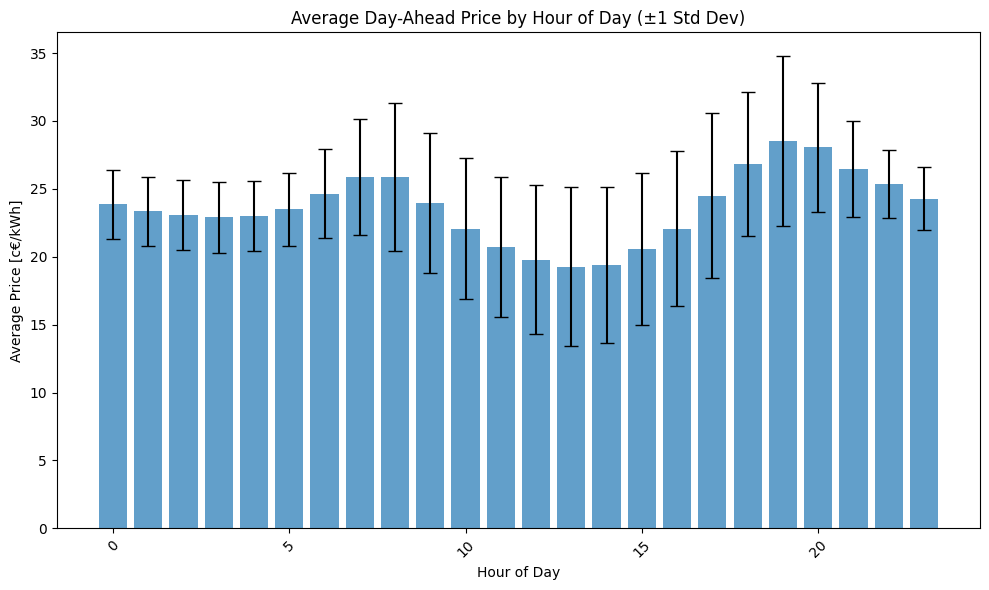

In [226]:
# Group by day of week and calculate mean and std
df_usage_and_price['hour_of_day'] = df_usage_and_price['datetime'].dt.hour

# Calculate mean and std for each day of week
daily_stats = df_usage_and_price.groupby('hour_of_day')['c_variable_and_fixed_per_kwh'].agg(['mean', 'std']).reset_index()

# # Order days of week correctly
#      = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# daily_stats['day_of_week'] = pd.Categorical(daily_stats['day_of_week'], categories=day_order, ordered=True)
# daily_stats = daily_stats.sort_values('day_of_week')

# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(daily_stats['hour_of_day'], daily_stats['mean'], yerr=daily_stats['std'], capsize=5, alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Average Price [c€/kWh]')
plt.title('Average Day-Ahead Price by Hour of Day (±1 Std Dev)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

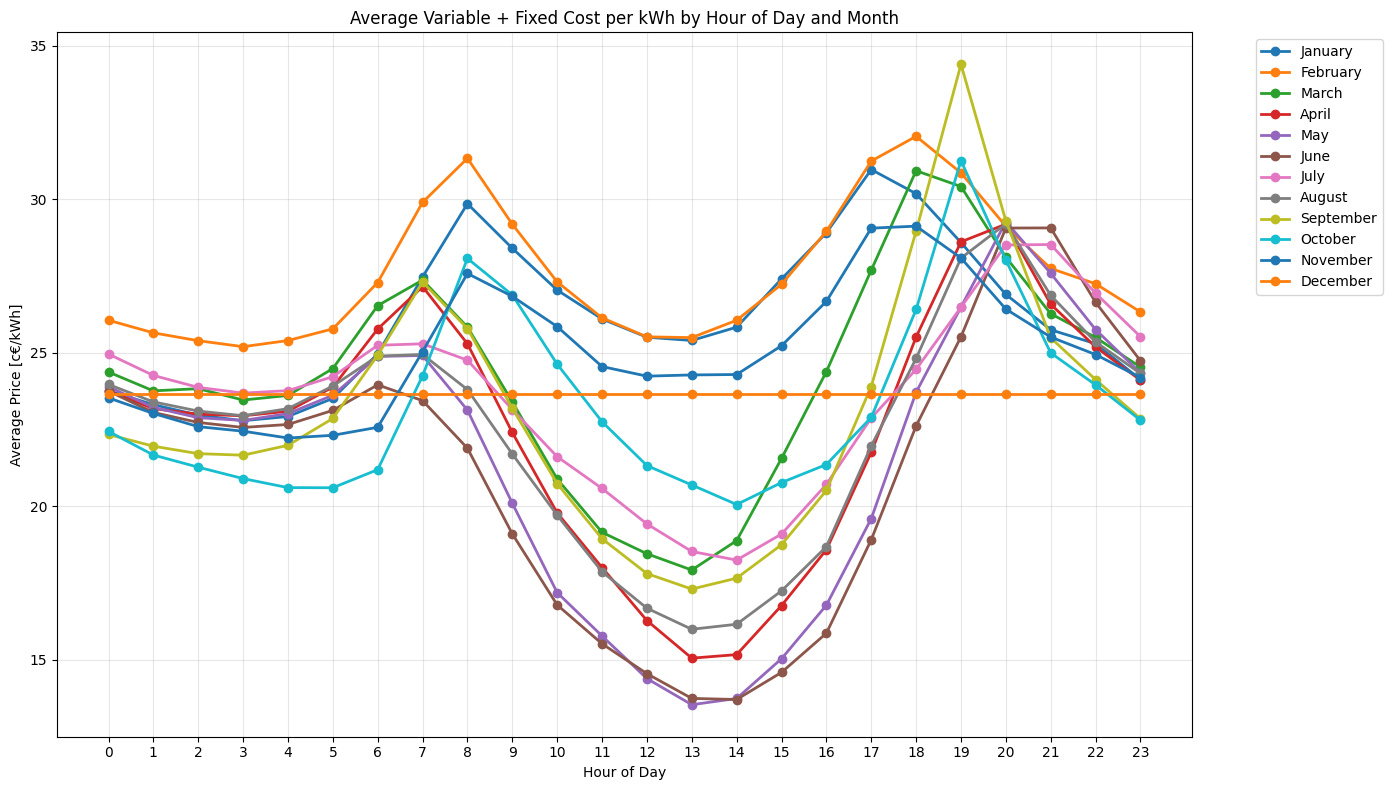

In [227]:
# Create a pivot table with hour of day as rows and month as columns
df_usage_and_price['month'] = df_usage_and_price['datetime'].dt.month
df_usage_and_price['month_name'] = df_usage_and_price['datetime'].dt.strftime('%B')
df_usage_and_price['hour_of_day'] = df_usage_and_price['datetime'].dt.hour

# Calculate average price by hour and month
hourly_monthly_avg = df_usage_and_price.groupby(['hour_of_day', 'month_name'])['c_variable_and_fixed_per_kwh'].mean().reset_index()

# Get unique months in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
months_in_data = [m for m in month_order if m in hourly_monthly_avg['month_name'].unique()]

# Create the plot
plt.figure(figsize=(14, 8))

for month in months_in_data:
    month_data = hourly_monthly_avg[hourly_monthly_avg['month_name'] == month]
    plt.plot(month_data['hour_of_day'], month_data['c_variable_and_fixed_per_kwh'], 
             marker='o', label=month, linewidth=2)

plt.xlabel('Hour of Day')
plt.ylabel('Average Price [c€/kWh]')
plt.title('Average Variable + Fixed Cost per kWh by Hour of Day and Month')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

np.float64(1.0000000000000002)

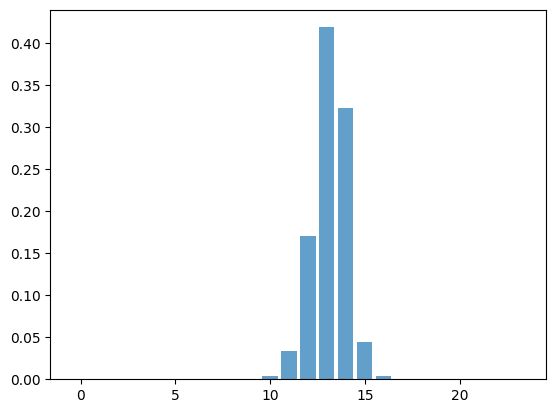

In [213]:
daily_stats = df_usage_and_price.groupby('hour_of_day')['c_per_kwh_variable'].agg(['mean', 'std']).reset_index()

daily_stats["weighted_mean"] = daily_stats["mean"] / daily_stats["mean"].sum()
daily_stats["inverse_weighted_mean"] = daily_stats["weighted_mean"].max() - daily_stats["weighted_mean"]
daily_stats["inverse_weighted_mean"] = (daily_stats["inverse_weighted_mean"] / daily_stats["inverse_weighted_mean"].sum()) * 10
# daily_stats["inverse_weighted_mean"] = daily_stats["weighted_mean"]

def temperature_weighting(df: pd.DataFrame, T: float) -> pd.DataFrame:
    x = df["inverse_weighted_mean"].values

    # numerically stable softmax: subtract max before exp()
    z = (x / T) # - np.max(x * T)
    exp_z = np.exp(z)
    df["temp_weighted"] = exp_z / exp_z.sum()

    return df

daily_stats = temperature_weighting(daily_stats, T=0.05)

plt.bar(daily_stats['hour_of_day'], daily_stats['temp_weighted'], capsize=5, alpha=0.7)

daily_stats["temp_weighted"].sum()


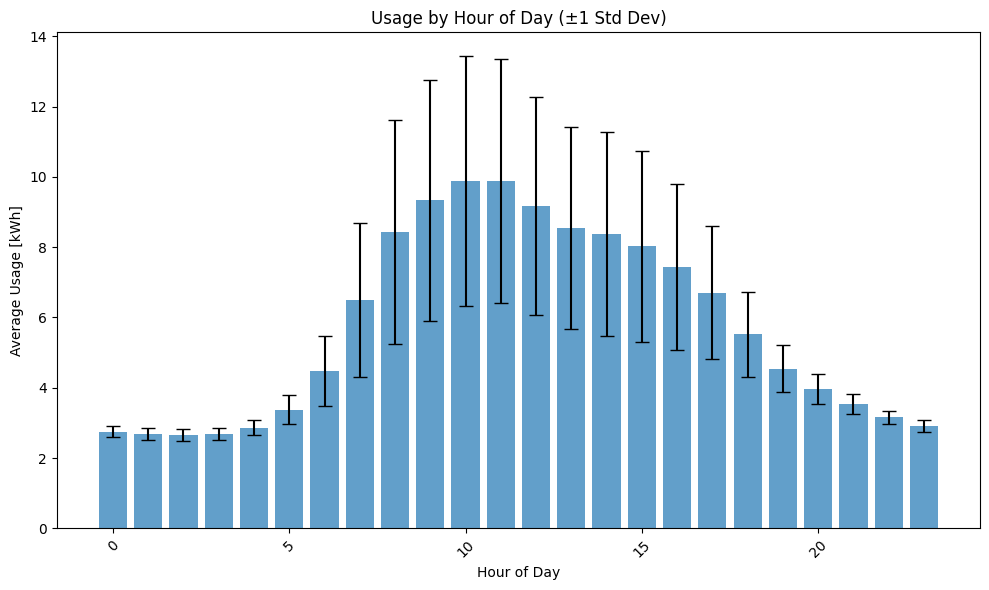

In [193]:
# Group by day of week and calculate mean and std
df_usage_and_price['hour_of_day'] = df_usage_and_price['datetime'].dt.hour

# Calculate mean and std for each day of week
daily_stats = df_usage_and_price.groupby('hour_of_day')['scaled_kwh_usage'].agg(['mean', 'std']).reset_index()

# # Order days of week correctly
#      = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# daily_stats['day_of_week'] = pd.Categorical(daily_stats['day_of_week'], categories=day_order, ordered=True)
# daily_stats = daily_stats.sort_values('day_of_week')

# Create bar plot with error bars
plt.figure(figsize=(10, 6))
plt.bar(daily_stats['hour_of_day'], daily_stats['mean'], yerr=daily_stats['std'], capsize=5, alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Average Usage [kWh]')
plt.title('Usage by Hour of Day (±1 Std Dev)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

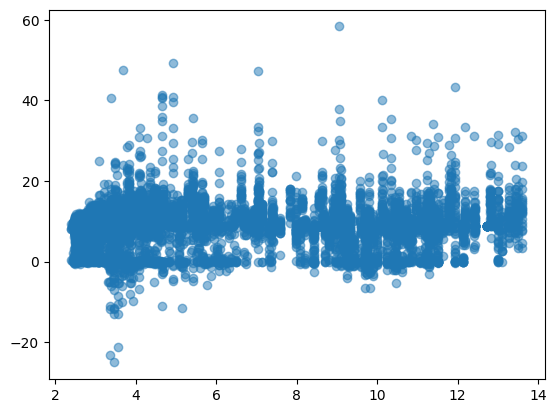

In [183]:
plt.scatter(df_usage_and_price["scaled_kwh_usage"], df_usage_and_price["c_per_kwh_variable"], alpha=0.5)


In [184]:
df_usage_and_price["scaled_kwh_usage"].corr(df_usage_and_price["c_per_kwh_variable"])

np.float64(0.010076219571153726)

In [185]:
df_usage_and_price.c_total_variable_cost.sum(), df_usage_and_price.c_total_flat_cost.sum()

(1413936.470733306, 1790231.5904549991)

In [186]:
def scale_usage_for_shifted_electricity(df, shift_proportion: float):
    df_snippet = df.copy()
    # Thoughts: There's probably only a proportion of one's electricity usage that can be shifted
    df_snippet.loc[:, "shifted_usage_scaled"] = df_snippet["scaled_kwh_usage"].shift(12).fillna(df_snippet["scaled_kwh_usage"].mean())

    original_area = df_snippet["scaled_kwh_usage"].sum()
    shifted_area = df_snippet["shifted_usage_scaled"].sum()
    print(f"shifted_area: {shifted_area:.2f}")
    alpha = original_area / (original_area + shift_proportion * shifted_area)
    shifted_weight = alpha * shift_proportion

    df_snippet["shifted_usage_scaled"] = (df_snippet["shifted_usage_scaled"] * alpha) * 1 # Multiply this for the energy lost
    df_snippet["scaled_kwh_usage"] = df_snippet["scaled_kwh_usage"] * shifted_weight
    df_snippet["combined_shifted_scaled_usage_kwh"] = df_snippet["shifted_usage_scaled"] + df_snippet["scaled_kwh_usage"]

    print(f"combined_shifted_area: {df_snippet['combined_shifted_scaled_usage_kwh'].sum():.2f}")
    
    return df_snippet

In [217]:
def shift_fraction(df, p: float, shift_steps: int = 12):
    df = df.copy()
    base = df["scaled_kwh_usage"]
    shifted = base.shift(shift_steps)
    df["shifted_scaled_kwh_usage"] = shifted

    df["scaled_kwh_usage_comb"] = (1 - p) * base
    df["shifted_usage_scaled"] = p * shifted.fillna(shifted.mean())
    df["combined_shifted_scaled_usage_kwh"] = df["scaled_kwh_usage_comb"] + df["shifted_usage_scaled"]

    print("original:", base.sum())
    # print("combined:", df["combined_shifted_scaled_usage_kwh"].sum())
    print(f'combined: {  (df["scaled_kwh_usage_comb"] + df["shifted_usage_scaled"]).sum() }')

    return df

def shift_to_time(df, daily_stats: pd.DataFrame, p: float = 0.5):
    """This function shifts electricity to be used primarily during hours when it is cheaper, which from 11h00 - 16h00

    Args:
        df (pd.DataFrame) - the dateframe
        hour_range (list) - hours to shift the electricity usage to
        p (float) - proportion of electricity to shift
    
    Returns: 
        pd.DataFrame

    """

    df = df.copy()

    df = df.merge(
        daily_stats[["hour_of_day", "temp_weighted"]],
        left_on=df["datetime"].dt.hour,
        right_on="hour_of_day",
        how="left"
    )

    df["day_of_year"] = df["datetime"].dt.dayofyear
    
    usage_by_day = df.groupby("day_of_year", as_index=False)["scaled_kwh_usage"].sum()
    usage_by_day.rename(columns={"scaled_kwh_usage": "daily_total_usage_kwh"}, inplace=True)
    
    df = df.merge(
        usage_by_day,
        on="day_of_year",
        how="left"
    )

    df["prop_shifted_usage"] = df["temp_weighted"] * df["daily_total_usage_kwh"]

    df["c_total_variable_shifted_cost"] = df["prop_shifted_usage"] * (df["c_per_kwh_variable"] + df["c_fixed_costs_kwh"]) * (1 + TAX_RATE)

    df.drop(columns=["hour_of_day", "day_of_year", "hour_of_day_x", "hour_of_day_y", "temp_weighted", "daily_total_usage_kwh"], inplace=True)
    return df

In [221]:
# df_temp = df_usage_and_price[(df_usage_and_price["datetime"] >= "2025-02-01") & (df_usage_and_price["datetime"] <= "2025-02-14")]
df_temp = df_usage_and_price.copy()
df_snippet = shift_to_time(df_temp, daily_stats)
df_snippet

round(df_snippet["c_total_variable_shifted_cost"].sum(),1), round(df_snippet["c_total_variable_cost"].sum(),1)

print(f'Shifted usage sum: €{df_snippet["c_total_variable_shifted_cost"].sum():,.2f} kWh')
print(f'Original usage sum: €{df_snippet["c_total_variable_cost"].sum():,.2f} kWh')

Shifted usage sum: €1,205,320.59 kWh
Original usage sum: €1,413,936.47 kWh


In [219]:
df_snippet["prop_shifted_usage"].sum(), df_snippet["scaled_kwh_usage"].sum()

(50146.543149999685, 50146.5431500005)

In [80]:
df_temp = df_usage_and_price[(df_usage_and_price["datetime"] >= "2025-02-01") & (df_usage_and_price["datetime"] <= "2025-02-14")]
# df_snippet = scale_usage_for_shifted_electricity(df_temp, ELECTRICITY_SHIFT_PROPORTION)
df_snippet = shift_fraction(df_temp, ELECTRICITY_SHIFT_PROPORTION, shift_steps=14)


df_snippet["c_total_variable_shifted_cost"] = (
    (df_snippet["combined_shifted_scaled_usage_kwh"] * (df_snippet["c_per_kwh_variable"] + df_snippet["c_fixed_costs_kwh"])) * (1 + TAX_RATE)
)

original: 1956.3646999999978
combined: 1946.230555769232


/var/folders/mz/1tq8q4z116lfkx_8zp09v6wh0000gn/T/ipykernel_6854/3412376895.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["shifted_usage_scaled"] = p * shifted.fillna(shifted.mean())


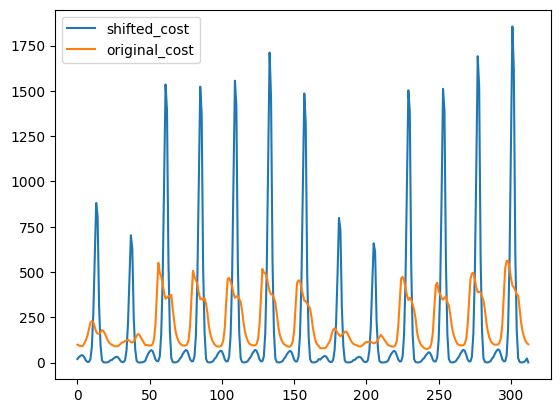

In [201]:
plt.plot(df_snippet["c_total_variable_shifted_cost"], label="shifted_cost")
plt.plot(df_snippet["c_total_variable_cost"], label="original_cost")
# plt.plot(df_snippet["scaled_kwh_usage"], label="scaled_kwh_usage")
# plt.plot(df_snippet["prop_shifted_usage"], label="shifted_usage")
# plt.plot(df_snippet["combined_shifted_scaled_usage_kwh"], label="combined_shifted_scaled_usage_kwh", c="green")
plt.legend()

In [199]:
df_snippet["scaled_kwh_usage"].sum(), df_snippet["prop_shifted_usage"].sum()

(1956.3646999999978, 1953.4261868535923)

In [84]:
df_snippet["c_total_variable_shifted_cost"].sum(), df_snippet["c_total_variable_cost"].sum()

(66123.49463952504, 67737.42682027996)

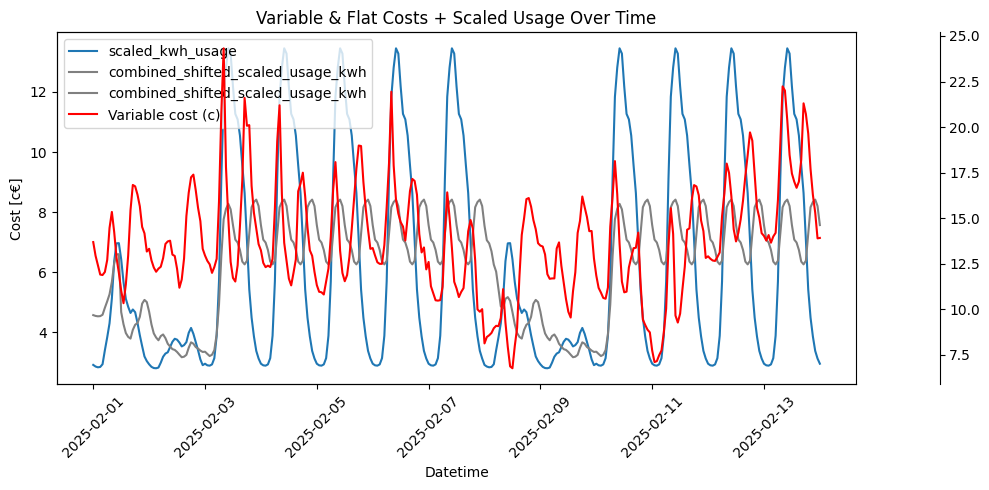

In [76]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Primary axis (left) ---
# ax1.plot(df_snippet["datetime"], df_snippet["c_per_kwh_variable"], label="Variable cost (c)")
# ax1.plot(df_snippet["datetime"], df_snippet["c_total_flat_cost"], label="Total Flat Cost")
ax1.plot(df_snippet["datetime"], df_snippet["scaled_kwh_usage"], label="scaled_kwh_usage")
ax1.plot(df_snippet["datetime"], df_snippet["combined_shifted_scaled_usage_kwh"], color="grey", label="combined_shifted_scaled_usage_kwh")
# ax1.plot(df_snippet["datetime"], df_snippet["c_total_variable_shifted_cost"], label="Cost with Shifted Usage")

ax1.set_xlabel("Datetime")
ax1.set_ylabel("Cost [c€]")
ax1.tick_params(axis='x', rotation=45)

# --- Secondary axis (right) ---
# ax2 = ax1.twinx()
# ax2.plot(df_snippet["datetime"], df_snippet["combined_shifted_scaled_usage_kwh"], color="grey", label="combined_shifted_scaled_usage_kwh")
# # ax2.plot(df_snippet["datetime"], df_snippet["shifted_usage"], color="green", linestyle="--", label="Shifted kWh Usage")
# ax2.set_ylabel("Scaled kWh Usage")

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset
ax3.plot(df_snippet["datetime"], df_snippet["c_per_kwh_variable"], label="Variable cost (c)", c="red")

# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc="upper left")

plt.title("Variable & Flat Costs + Scaled Usage Over Time")
plt.tight_layout()
plt.show()

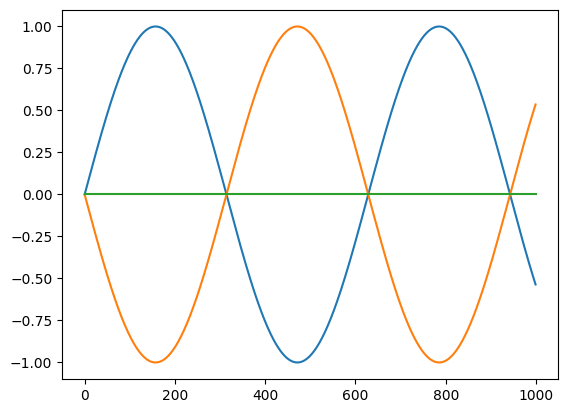

In [20]:
import numpy as np
x1 = np.sin(np.arange(0, 10, 0.01))
x2 = np.sin(np.arange(np.pi, 10+np.pi, 0.01))

x3 = 0.5 * x1 + 0.5 * x2

plt.plot(x1)
plt.plot(x2)
plt.plot(x3)
